# Track 2: Data Scarcity & Robustness
**Question:** *When does the quantum encoding help?*

Three experiments:
- **2A** Learning curves — does the quantum gap grow when data is scarce?
- **2B** Noise robustness — at what noise level does the advantage vanish?
- **2C** Combinatorial shuffle — does inter-position structure matter?

## Setup

In [12]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import f1_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = 'data_tutorial/pqk'   # ← folder with the 4 CSVs

## Load Data

In [13]:
MOTIFS    = ['motif', 'motif.1', 'motif.2', 'motif.3']
LABEL     = 'Nalm 6 Cytotoxicity'
THRESHOLD = 0.62

def load_all(data_dir):
    tr = pd.read_csv(os.path.join(data_dir, 'train_data.csv'), encoding='unicode_escape')
    te = pd.read_csv(os.path.join(data_dir, 'test_data.csv'),  encoding='unicode_escape')
    for df in [tr, te]:
        df.replace(17, 14, inplace=True)
        df.columns = ['Cell Number','motif','motif.1','motif.2','motif.3','motif.4','Nalm 6 Cytotoxicity']
    last_motif_col = 'motif.3'  # 4th position (0-indexed: motif, motif.1, motif.2, motif.3)
    tr = tr[tr[last_motif_col] != 14].reset_index(drop=True)
    te = te[te[last_motif_col] != 14].reset_index(drop=True)
    def binarize(s):
        lbl = s.copy().astype(float).values
        lbl[lbl >  THRESHOLD] =  1
        lbl[lbl <= THRESHOLD] = -1
        return lbl.astype(int)

    train_labels = binarize(tr[LABEL])
    test_labels  = binarize(te[LABEL])

    # One-hot encode motifs
    tr_m = tr[MOTIFS].values; te_m = te[MOTIFS].values
    shift = min(tr_m.min(), te_m.min())
    tr_m -= shift; te_m -= shift
    nc = max(tr_m.max(), te_m.max()) + 1
    def oh(arr): return np.eye(nc)[arr].reshape(arr.shape[0], -1)

    proj_tr = pd.read_csv(os.path.join(data_dir, 'projections_train.csv'), header=0).values * (np.pi/2)
    proj_te = pd.read_csv(os.path.join(data_dir, 'projections_test.csv'),  header=0).values * (np.pi/2)

    # Store raw motif df for shuffle experiment
    return oh(tr_m), oh(te_m), train_labels, test_labels, proj_tr, proj_te, tr[MOTIFS].values - shift

train_data, test_data, train_labels, test_labels, \
proj_tr, proj_te, raw_motifs_train = load_all(DATA_DIR)

print('train:', train_data.shape, '| proj:', proj_tr.shape)
print('test: ', test_data.shape,  '| proj:', proj_te.shape)
print('class balance (train):', dict(zip(*np.unique(train_labels, return_counts=True))))

train: (17, 60) | proj: (171, 180)
test:  (15, 60) | proj: (73, 180)
class balance (train): {np.int64(-1): np.int64(10), np.int64(1): np.int64(7)}


In [14]:
# Shared SVM trainer
PARAM_GRID = {
    'C':     [0.1, 0.5, 1, 2.5, 5, 7.5, 8.5, 10, 10.75, 15, 25, 50, 100],
    'gamma': ['auto','scale', 0.001, 0.005, 0.01, 0.02, 0.04, 0.05, 0.1, 0.25, 0.5, 1],
}
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

def train_eval(X_tr, y_tr, X_te, y_te):
    # Use fewer folds when training set is small
    n_splits = min(10, len(y_tr) // 5)
    n_splits = max(n_splits, 2)  # never go below 2
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(SVC(kernel='rbf'), PARAM_GRID, cv=cv,
                      scoring='f1_weighted', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    return f1_score(y_te, gs.predict(X_te), average='weighted')

---
## Experiment 2A — Learning Curves
**Hypothesis:** quantum advantage is largest when training data is scarce and shrinks as data grows.

In [15]:
FRACTIONS = [0.25, 0.35, 0.5, 0.65, 0.75, 1.0]
N_SEEDS   = 5   # repeat per fraction for error bars

lc_results = []   # list of dicts

for frac in FRACTIONS:
    f1c_runs, f1q_runs = [], []
    for seed in range(N_SEEDS):
        if frac == 1.0:
            idx = np.arange(len(train_labels))
        else:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=seed)
            idx, _ = next(sss.split(train_data, train_labels))

        f1c = train_eval(train_data[idx], train_labels[idx], test_data,  test_labels)
        f1q = train_eval(proj_tr[idx],    train_labels[idx], proj_te,    test_labels)
        f1c_runs.append(f1c); f1q_runs.append(f1q)
        print(f'  frac={frac:.2f} seed={seed}  classical={f1c:.4f}  quantum={f1q:.4f}')

    n = int(frac * len(train_labels))
    lc_results.append(dict(
        n=n, frac=frac,
        c_mean=np.mean(f1c_runs), c_std=np.std(f1c_runs),
        q_mean=np.mean(f1q_runs), q_std=np.std(f1q_runs),
    ))

lc = pd.DataFrame(lc_results)
print(lc.to_string(index=False))

ValueError: Found input variables with inconsistent numbers of samples: [15, 73]

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# F1 vs training size
ax1.errorbar(lc['n'], lc['c_mean'], yerr=lc['c_std'], fmt='o-',
             color='#3498db', capsize=4, label='Classical')
ax1.errorbar(lc['n'], lc['q_mean'], yerr=lc['q_std'], fmt='s-',
             color='#e74c3c', capsize=4, label='Quantum-projected')
ax1.fill_between(lc['n'], lc['c_mean'], lc['q_mean'], alpha=0.12, color='purple')
ax1.set_xlabel('Training samples'); ax1.set_ylabel('Weighted F1 (test)')
ax1.set_title('2A: Learning curves (mean ± std, 5 seeds)')
ax1.legend(); ax1.grid(alpha=0.3)

# ΔF1 vs training size
delta = lc['q_mean'] - lc['c_mean']
ax2.bar(lc['n'].astype(str), delta, color=['#e74c3c' if d > 0 else '#3498db' for d in delta])
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Training samples'); ax2.set_ylabel('ΔF1 (quantum − classical)')
ax2.set_title('2A: Quantum advantage by data size')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

---
## Experiment 2B — Noise Robustness
**Hypothesis:** Quantum projections are at least as robust as classical features to added noise.

We standardize both representations before adding noise so σ values are on the same relative scale.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize (fit on train, apply to test)
sc_c = StandardScaler().fit(train_data)
sc_q = StandardScaler().fit(proj_tr)

X_c_tr = sc_c.transform(train_data); X_c_te = sc_c.transform(test_data)
X_q_tr = sc_q.transform(proj_tr);   X_q_te = sc_q.transform(proj_te)

NOISE_LEVELS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
N_SEEDS_NOISE = 5

noise_results = []
for sigma in NOISE_LEVELS:
    f1c_runs, f1q_runs = [], []
    for seed in range(N_SEEDS_NOISE):
        rng = np.random.RandomState(seed)
        nc_tr = X_c_tr + rng.normal(0, sigma, X_c_tr.shape)
        nc_te = X_c_te + rng.normal(0, sigma, X_c_te.shape)
        nq_tr = X_q_tr + rng.normal(0, sigma, X_q_tr.shape)
        nq_te = X_q_te + rng.normal(0, sigma, X_q_te.shape)

        f1c_runs.append(train_eval(nc_tr, train_labels, nc_te, test_labels))
        f1q_runs.append(train_eval(nq_tr, train_labels, nq_te, test_labels))
        print(f'  σ={sigma}  seed={seed}  C={f1c_runs[-1]:.4f}  Q={f1q_runs[-1]:.4f}')

    noise_results.append(dict(
        sigma=sigma,
        c_mean=np.mean(f1c_runs), c_std=np.std(f1c_runs),
        q_mean=np.mean(f1q_runs), q_std=np.std(f1q_runs),
    ))

nr = pd.DataFrame(noise_results)
print(nr.to_string(index=False))

ValueError: Found input variables with inconsistent numbers of samples: [171, 17]

NameError: name 'nr' is not defined

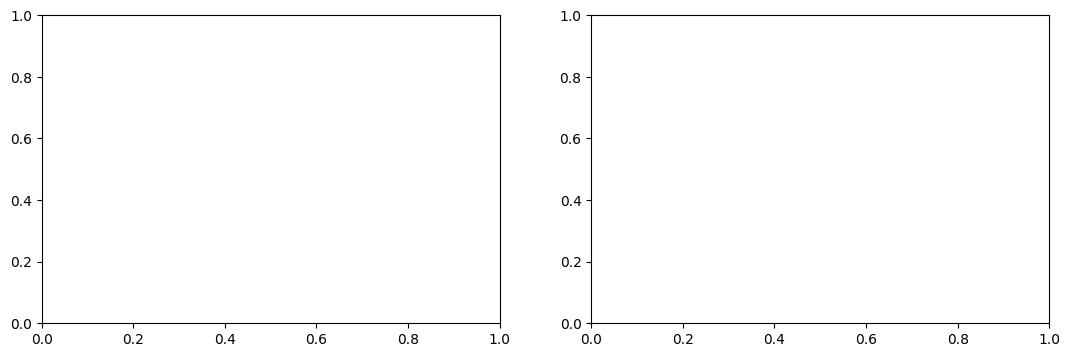

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.errorbar(nr['sigma'], nr['c_mean'], yerr=nr['c_std'], fmt='o-',
             color='#3498db', capsize=4, label='Classical')
ax1.errorbar(nr['sigma'], nr['q_mean'], yerr=nr['q_std'], fmt='s-',
             color='#e74c3c', capsize=4, label='Quantum-projected')
ax1.set_xlabel('Noise σ (std units, both representations standardized)')
ax1.set_ylabel('Weighted F1 (test)')
ax1.set_title('2B: Robustness to Gaussian noise (mean ± std, 5 seeds)')
ax1.legend(); ax1.grid(alpha=0.3)

delta_n = nr['q_mean'] - nr['c_mean']
ax2.plot(nr['sigma'], delta_n, 'o-', color='purple')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Noise σ'); ax2.set_ylabel('ΔF1 (quantum − classical)')
ax2.set_title('2B: Quantum advantage vs noise level')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Experiment 2C — Combinatorial Shuffle
**Hypothesis:** If inter-position structure matters, shuffling motif assignments within each position column across training samples should hurt performance — because the model can no longer learn which combinations predict cytotoxicity.

**Method:** Permute each position column of the *training* motifs independently. Test set is unchanged.

In [ ]:
N_SHUFFLES = 10   # repeat to get stable mean

# Baseline (no shuffle) — use full training set
f1c_base = train_eval(train_data, train_labels, test_data, test_labels)
print(f'Classical baseline (no shuffle): F1 = {f1c_base:.4f}')

# One-hot encoder to rebuild features from shuffled raw motifs
all_motifs = raw_motifs_train
nc = int(all_motifs.max()) + 1
def oh(arr): return np.eye(nc)[arr].reshape(arr.shape[0], -1)

shuffle_f1s = []
for seed in range(N_SHUFFLES):
    rng = np.random.RandomState(seed)
    shuffled = all_motifs.copy()
    for col in range(shuffled.shape[1]):
        shuffled[:, col] = rng.permutation(shuffled[:, col])
    X_shuf = oh(shuffled)
    f1 = train_eval(X_shuf, train_labels, test_data, test_labels)
    shuffle_f1s.append(f1)
    print(f'  shuffle seed={seed}  F1={f1:.4f}')

print(f'\nShuffled mean ± std: {np.mean(shuffle_f1s):.4f} ± {np.std(shuffle_f1s):.4f}')
print(f'Baseline:            {f1c_base:.4f}')
print(f'Drop from shuffle:   {f1c_base - np.mean(shuffle_f1s):+.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(f1c_base, color='#3498db', linewidth=2, label=f'Classical baseline ({f1c_base:.4f})')
ax.scatter(range(N_SHUFFLES), shuffle_f1s, color='gray', zorder=3, label='Shuffled runs')
ax.axhline(np.mean(shuffle_f1s), color='gray', linestyle='--',
           label=f'Shuffled mean ({np.mean(shuffle_f1s):.4f})')
ax.fill_between([-0.5, N_SHUFFLES-0.5],
                np.mean(shuffle_f1s)-np.std(shuffle_f1s),
                np.mean(shuffle_f1s)+np.std(shuffle_f1s),
                alpha=0.15, color='gray')
ax.set_xlabel('Shuffle run'); ax.set_ylabel('Weighted F1 (test)')
ax.set_title('2C: Combinatorial structure — effect of position-column shuffle')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary Table

In [ ]:
print('=== Track 2 Summary ===')
print()
print('2A — Learning curves')
print(lc[['n','c_mean','q_mean']].assign(delta=lc['q_mean']-lc['c_mean']).to_string(index=False))
print()
print('2B — Noise robustness')
print(nr[['sigma','c_mean','q_mean']].assign(delta=nr['q_mean']-nr['c_mean']).to_string(index=False))
print()
print('2C — Combinatorial shuffle')
print(f'  Baseline F1:     {f1c_base:.4f}')
print(f'  Shuffled F1:     {np.mean(shuffle_f1s):.4f} ± {np.std(shuffle_f1s):.4f}')
print(f'  Performance drop:{f1c_base - np.mean(shuffle_f1s):+.4f}')